In [3]:
#!pip install --upgrade tensorflow[and-cuda]

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import tensorflow as tf

technical analysis focuses on analyzing direction of prices to predict future prices  
  
fundamental analysis such as analyzing financial news and earning reports   
fundamental analysis using ML is mostly text and sentiment  

problem: data  

we often don't get the 'outcome' from social media data  

we need to solve the problem in an unsupervised way which could be a hit or miss  

conclusion:  
technical analysis is pure numbers   --> perfect for deep learning  

data is from open-source python libraries  

In [5]:
!nvidia-smi

Failed to initialize NVML: N/A
Failed to properly shut down NVML: N/A



In [16]:
data = yf.download('GOOGL',start='2018-01-01',end='2025-11-13',interval='1d',auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


# the end date was 11/12/2025

In [17]:
data.shape

(1978, 5)

In [18]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2025-11-06,284.750000,288.350006,281.140015,285.329987,37173600
2025-11-07,278.829987,283.779999,275.190002,283.209991,34479600
2025-11-10,290.100006,290.799988,282.859985,284.420013,29557300
2025-11-11,291.309998,291.920013,287.320007,287.750000,19842100
2025-11-12,286.709991,292.010010,283.690002,291.679993,24829900


it is up to sentiment to drive stock high or low  

adjusted acounts for splits, dividends, rights offerings etc

volume ==> number of shares traded a period in time; it determines market interest and liquidity of a particular stock    
(if purchases increase, supply decreases, and evnentuall market evaluation increases)  
volume growth and price increase, volume shrinkage and volume decrease, all are indecators of buyer interest/sentiment    

example: it is up to sentiment whether google is high or low


In [19]:
data.sort_index(inplace=True)
data = data[~data.index.duplicated(keep='first')]#.dulicated returns a boolean of repeated except 'first'

In [20]:
data.shape

(1978, 5)

In [21]:
data.isna().sum()

Price   Ticker
Close   GOOGL     0
High    GOOGL     0
Low     GOOGL     0
Open    GOOGL     0
Volume  GOOGL     0
dtype: int64

In [22]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,1978.000000,1978.000000,1978.000000,1978.000000,1.978000e+03
mean,111.330892,112.531760,110.052524,111.257888,3.401904e+07
std,48.682552,49.176170,48.111031,48.631122,1.531652e+07
min,48.896263,50.259359,48.548162,48.878881,9.312000e+06
25%,63.453106,64.076061,62.742265,63.325735,2.424005e+07
50%,107.016891,108.120034,105.095148,106.386489,3.034950e+07
75%,141.940033,143.299153,140.386356,142.080813,3.878960e+07
max,291.309998,292.010010,287.320007,291.679993,1.331780e+08


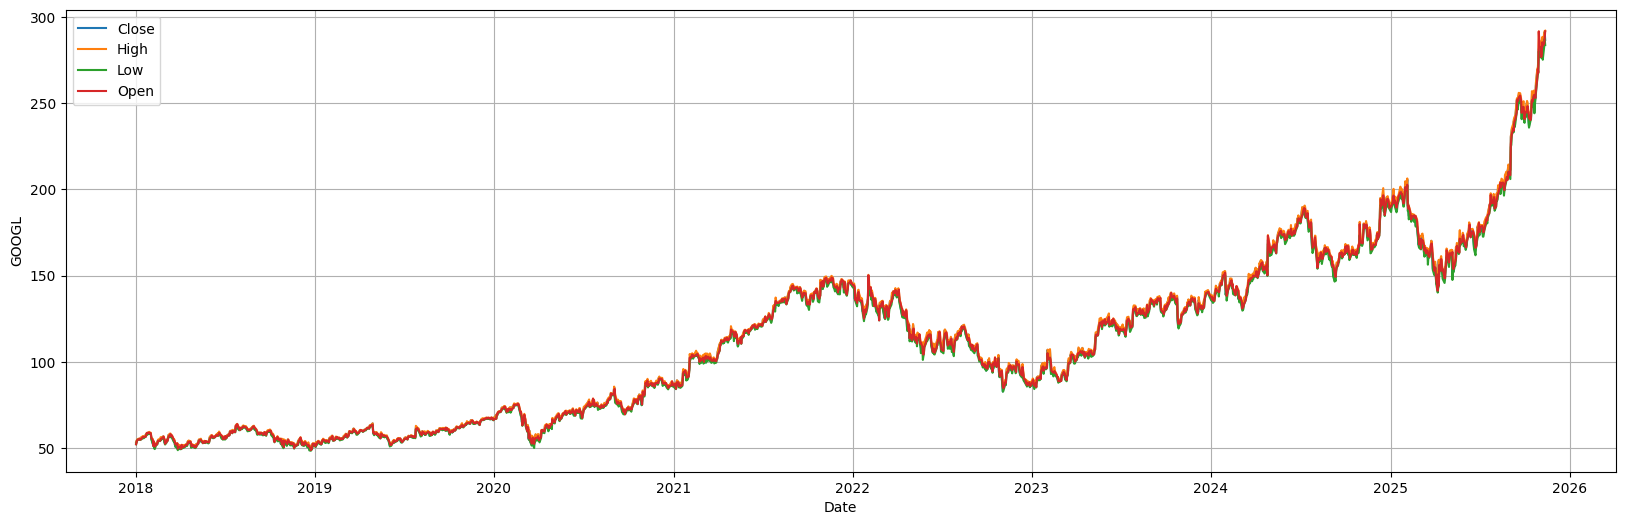

In [23]:
x = data.index
# ensure y is 1-dimensional (Series), not a single-column DataFrame
y = data['Close'].squeeze()
y2 = data['High'].squeeze()
y3 = data['Low'].squeeze()
y4 = data['Open'].squeeze()
plt.rcParams['figure.figsize']=(20,6)
sns.lineplot(x=x, y=y,label='Close')
sns.lineplot(x=x,y=y2,label='High')
sns.lineplot(x=x,y=y3,label='Low')
sns.lineplot(x=x,y=y4,label='Open')
plt.legend()
plt.grid()
plt.show()

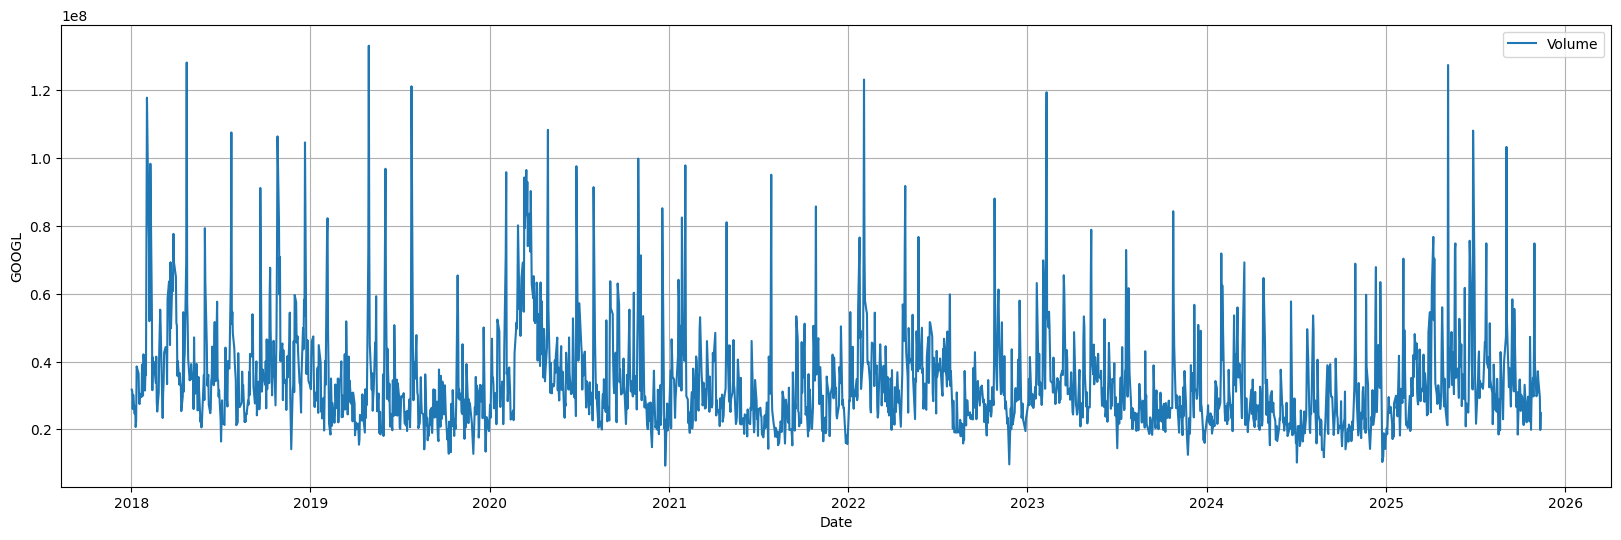

In [24]:
x = data.index
y5 = data['Volume'].squeeze()
plt.rcParams['figure.figsize']=(20,6)
#sns.lineplot(x=x, y=y,label='Close')
sns.lineplot(x=x, y=y5,label='Volume')
plt.legend()
plt.grid()
plt.show()

preprocess for the deep learning model:  

In [25]:
from sklearn.preprocessing import MinMaxScaler
import pickle
from tqdm.notebook import tnrange

In [26]:
#filter to required data
data=data[['Close','Volume']]
data.head()

Price,Close,Volume
Ticker,GOOGL,GOOGL
Date,,
2018-01-02,53.292931,31766000
2018-01-03,54.202164,31318000
2018-01-04,54.412708,26052000
2018-01-05,55.134232,30250000
2018-01-08,55.328892,24644000


In [27]:
print(f'tail: {data.tail(1)}')
print(f'shape: {data.shape}')

tail: Price            Close    Volume
Ticker           GOOGL     GOOGL
Date                            
2025-11-12  286.709991  24829900
shape: (1978, 2)


## test length at about 10%

In [28]:
# confirm the testing set length
test_length = data[(data.index>='2025-02-01')].shape[0]
test_length

197

In [29]:
from tqdm import tqdm
def create_features_and_targets(dataframe,feature_length):
    data=dataframe.copy()
    X,y=[],[]
    for i in tqdm(range(len(data)-feature_length)):
        X.append(data.iloc[i:i+feature_length,:].values)
        y.append(data['Close'].values[i+feature_length])
    X,y=np.array(X),np.array(y)
    return X,y

In [30]:
X,y=create_features_and_targets(data,32)

100%|██████████| 1946/1946 [00:00<00:00, 2812.16it/s]


In [31]:


print(f'X shape: {X.shape}\ny shape: {y.shape}')

X shape: (1946, 32, 2)
y shape: (1946, 1)


In [32]:
#records, frames, observaions
X[:1,11:12,1].shape,X[:1,11:12,0],X[:1,11:12,1],X[:1,11:12,:],X[:,:,1].shape

((1, 1),
 array([[56.40943909]]),
 array([[27498000.]]),
 array([[[5.64094391e+01, 2.74980000e+07]]]),
 (1946, 32))

In [33]:
Xtrain,Xtest,ytrain,ytest = X[:-test_length],X[-test_length:],y[:-test_length],y[-test_length:]


In [34]:
Xtrain.shape,Xtest.shape,ytrain.shape,ytest.shape

((1749, 32, 2), (197, 32, 2), (1749, 1), (197, 1))

In [46]:
# a scaling class to handle multidimensional vectors
class MultiDimensionScaler:
    def __init__(self):
        self.scalers = []

    def fit_transform(self,Xtr):
        Xtrain=Xtr.copy()
        total_dims=Xtrain.shape[2]
        for i in tqdm(range(total_dims)):
            Scaler = MinMaxScaler()
            Xtrain[:,:,i] = Scaler.fit_transform(Xtrain[:,:,i])
            self.scalers.append(Scaler)
        return Xtrain
    
    def transform(self,Xte):
        Xtest=Xte.copy()
        total_dims=Xtest.shape[2]
        for i in tqdm(range(total_dims)):
            Xtest[:,:,i] = self.scalers[i].transform(Xtest[:,:,i])
        return Xtest
        

In [36]:
mnmx=MultiDimensionScaler()
Xtrain_scaled=mnmx.fit_transform(Xtrain)
Xtest_scaled=mnmx.transform(Xtest)

100%|██████████| 2/2 [00:00<00:00, 1850.97it/s]


In [37]:
target_mnmx=MinMaxScaler()
ytrain_scaled=target_mnmx.fit_transform(ytrain)
ytest_scaled=target_mnmx.transform(ytest)

In [ ]:
dfghjk

In [ ]:
def save_object(obj,name:str):
    with open(f"{name}.pck",'wb') as m:
        pickle.dump(obj,m)

def load_object(name:str):
    with open(f"{name}.pck",'rb') as m:
        res=pickle.load(m)
        return res

In [ ]:
save_object(mnmx,'X_scaler')
save_object(target_mnmx,'y_scaler')

## Deep Learning Model  
### 

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau


save_best = ModelCheckpoint("best.weights.h5",monitor='val_loss',save_best_only=True,save_weights_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.25,patience=5,min_lr=0.00001,verbose=1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional

model = Sequential()
model.add(Bidirectional(LSTM(512,return_sequences=True,recurrent_dropout=0.1,input_shape=(32,2))))#return_sequence=True will output a sequence
model.add(LSTM(256,recurrent_dropout=0.1))# if 2 lstm layer, the first should have return_sequence=True
model.add(Dropout(0.3))
model.add(Dense(64,activation='elu'))# elu is modified 'leaky relu' it looks like relu and tanh activation merged together
model.add(Dropout(0.3))
model.add(Dense(32,activation='elu'))
model.add(Dense(1,activation='linear')) #outputs a continuous value


/mnt/c/Users/user/OneDrive/Documents/D_I_G/ML/Deep_Learning/stock_market_prediction/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.002)# the lecturer said she's experienced better results on small batch sizes with sgd (complex problem->frequent updates->small batch size)
model.compile(loss='mse',optimizer=optimizer)

In [ ]:
history = model.fit(Xtrain_scaled,
                    ytrain_scaled,
                    epochs=10,
                    batch_size=1,
                    verbose=True,
                    validation_data=(Xtest_scaled,ytest_scaled),
                    callbacks=[reduce_lr,save_best]
)




In [ ]:
plt.figure(figsize=(20,3))
x=[i for i in len(history.history['loss'])]
sns.lineplot(x=x,y=history.history['loss'],label='loss')
sns.lineplot(x=x,y=history.history['val_loss'])
plt.legend()
plt.grid()
plt.show()

dict_keys(['loss', 'val_loss', 'learning_rate'])

In [ ]:
"""
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional

def get_model():
    model = Sequential()
    model.add(Bidirectional(LSTM(512,return_sequences=True,recurrent_dropout=0.1,input_shape=(32,2))))#return_sequence=True will output a sequence
    model.add(LSTM(256,recurrent_dropout=0.1))# if 2 lstm layer, the first should have return_sequence=True
    model.add(Dropout(0.3))
    model.add(Dense(64,activation='elu'))# elu is modified 'leaky relu' it looks like relu and tanh activation merged together
    model.add(Dropout(0.3))
    model.add(Dense(32,activation='elu'))
    model.add(Dense(1,activation='linear')) #outputs a continuous value
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.002)# the lecturer said she's experienced better results on small batch sizes with sgd (complex problem->frequent updates->small batch size)
    model.compile(loss='mse',optimizer=optimizer)
    model.build(input_shape=(None,32,2))
    return model

from tensorflow import keras
model = get_model()
"""
"""
test_model = Sequential([
    Bidirectional(LSTM(512,return_sequences=True,recurrent_dropout=0.1,input_shape=(32,2))),
    LSTM(256,recurrent_dropout=0.1),Dropout(0.3),
    Dense(64,activation='elu'),
    Dropout(0.3),
    Dense(32,activation='elu'),
    Dense(1,activation='linear')
])

test_model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate=0.002),loss='mse')
test_model.summary()
"""

In [ ]:
model.load_weights("best.weights.h5")

In [ ]:
version=tf.__version__

In [ ]:
#test_model.save('2018-25_google_model.keras')#,save_format='tf')


/mnt/c/Users/user/OneDrive/Documents/D_I_G/ML/Deep_Learning/stock_market_prediction/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [ ]:
'''txt=f"""This model was trained on close and volume, of size (-1,32,2)\non data from jan1 2018 to nov12 2025\ntest_model = Sequential(
    Bidirectional(LSTM(512,return_sequences=True,recurrent_dropout=0.1,input_shape=(32,2))),
    LSTM(256,recurrent_dropout=0.1),Dropout(0.3),
    Dense(64,activation='elu'),
    Dropout(0.3),
    Dense(32,activation='elu'),
    Dense(1,activation='linear')
)\ntensorflow version: {version}"""'''


In [ ]:
#test_model.load_weights("best.weights.h5")
#with open('2018-25_google_model.txt','w') as text:
    #text.write(txt)


In [ ]:

model.load_weights("best.weights.h5")


In [ ]:
from sklearn.preprocessing import MinMaxScaler
def load_object(name:str):
    with open(f"{name}.pck",'rb') as m:
        res=pickle.load(m)
        return res
y_scaler=load_object('y_scaler')
#X_scaler=load_object('X_scaler')
predictions = model.predict(Xtest_scaled)
predictions = y_scaler.inverse_transform(predictions)
actual = y_scaler.inverse_transform(ytest_scaled)
predictions.shape
actual.shape
predicitons=np.squeeze(predictions,axis=1)
actual=np.squeeze(actual,axis=1)


In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(x=data.index[-test_length:],y=predictions,label='predictions',color='yellow',linewidth=3)
sns.lineplot(x=data.index[-test_length:],y=actual,label='actual',color='white')
plt.legend(fontsize=20)
plt.grid()
plt.gcf().set_facecolor('green')
plt.gca().set_facecolor('black')
plt.show()